In [1]:
from statsmodels.genmod.families.links import *
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cskpd_new import *
from convolution import convolution
from oasis_helpers import plot_model

with open('oasis.pkl', 'rb') as f:
    tra, cor, sag, Z, Y = pickle.load(f).values()

In [2]:
g = NegativeBinomial()
lam = [2**i for i in range(6)] # Use for both lambda values
R_list = 3
n_cores = 4
p_list = [[12,12],[24,24],[12,24],[24,12],[4,4]]

In [3]:
import numpy as np
import cv2

def resize_image(image):
    # Mask of non-zeros
    # initiate as 96x96
    # image = cv2.bilateralFilter(image,9,75,75)
    new_height, new_width = 96, 96
    mask = image != 0  # Use a >tolerance for a tolerance defining black border

    # Mask of non-zero rows and columns
    mask_row = mask.any(1)
    mask_col = mask.any(0)

    # First, last indices among the non-zero rows
    sr0, sr1 = mask_row.argmax(), len(mask_row) - mask_row[::-1].argmax()

    # First, last indices among the non-zero columns
    sc0, sc1 = mask_col.argmax(), len(mask_col) - mask_col[::-1].argmax()

    # Finally slice along the rows & cols with the start and stop indices to get
    # cropped image. Slicing helps for an efficient operation.
    cropped_image = image[sr0:sr1, sc0:sc1]

    # Original dimensions
    original_height, original_width = cropped_image.shape[:2]

    # Create an empty array for the resized image
    resized_image = np.zeros((new_height, new_width), dtype=np.float64)

    # Calculate the ratio of old dimensions to new dimensions
    row_ratio = original_height / new_height
    col_ratio = original_width / new_width

    # Map each pixel of the resized image to the nearest pixel of the original image
    for i in range(new_height):
        for j in range(new_width):
            # Find the nearest pixel in the original image
            original_i = int(i * row_ratio)
            original_j = int(j * col_ratio)

            # Assign the pixel value
            resized_image[i, j] = cropped_image[original_i, original_j]

    # Return the resized image and cropping boundaries
    return resized_image

def invert_resize_image(resized_image, original_height, original_width, sr0, sr1, sc0, sc1):
    # Calculate the height and width of the cropped image
    cropped_height = sr1 - sr0
    cropped_width = sc1 - sc0

    # Create an empty array for the cropped image
    cropped_image = np.zeros((cropped_height, cropped_width), dtype=np.float64)

    # Calculate the ratio of new dimensions to old dimensions
    row_ratio = cropped_height / resized_image.shape[0]
    col_ratio = cropped_width / resized_image.shape[1]

    # Map each pixel of the cropped image to the nearest pixel of the resized image
    for i in range(cropped_height):
        for j in range(cropped_width):
            # Find the nearest pixel in the resized image
            resized_i = int(i / row_ratio)
            resized_j = int(j / col_ratio)

            # Assign the pixel value
            cropped_image[i, j] = resized_image[resized_i, resized_j]

    # Create an empty array for the original image
    original_image = np.zeros((original_height, original_width), dtype=np.float64)

    # Place the cropped image back into its original position
    original_image[sr0:sr1, sc0:sc1] = cropped_image

    return original_image

In [4]:
K = convolution(resize_image, invert_resize_image)
K.convolve(tra[0])

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [5]:
from sklearn.metrics import roc_auc_score, mean_squared_error
def auc(y_true, y_pred):
    y_pred = np.array(y_pred) >= 0.5
    y_true = np.array(y_true) == 1
    return roc_auc_score(y_true, y_pred)
scorers = {
    'MSE': mean_squared_error,
    'AUC': auc
}

In [6]:
# Initialize a KFold object
kf = KFold(n_splits=5)
idx = np.array([y is not None for y in Y])
test = list(kf.split(np.array(cor)[idx]))

In [7]:
Y_logit = np.array([1 if x else 0 for x in np.array(Y)[idx] >= 0.5])
print(Y_logit)

[0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1
 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 1 0 0 1
 1 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0
 1 1 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 0
 1 1 0 0 1 0 1 0 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1
 1 0 0 0 1 0 1 1 1 1 0 0 0]


Appears to be a high degree of correlation between the size of the values of p and the lambda values.

In [20]:
idx = np.array([y is not None for y in Y])
# idx = [i for i, z in enumerate(Z) if z[0] >= 70 and z[0] < 80 and z[1] == 1]
g = Logit()
lam = [2**i for i in range(5,9)]
# lam = [1e4]
lamz = [2**i for i in range(-3,0)]
p_list = [[24,24],[24,12],[48,48]]
test_model = CSKPD(p_list,lama=lamz,lamb=0,lamz=0,R=3,g=g,n_cores = 1,max_iter = 5,print_iter = 5)
t1 = test_model.custom_cross_validate(np.array(cor)[idx],Y_logit, scorers=scorers, k_folds=5, K=K, Z=np.array(Z)[idx], tol=1e-3)
# t1 = test_model.custom_cross_validate(np.array(cor)[idx],np.array(Y, dtype=float)[idx], scorers=scorers, k_folds=5, K=K, tol=1e-3, Z=np.array(Z)[idx], max_vals=20)
# t1 = test_model.custom_cross_validate(zeros_x,np.array(Y)[idx], scorers=scorers, k_folds=5, tol=1e-3, Z=np.array(Z)[idx])

In [21]:
t1[0]['model'].grid_values['score']['history']

[array([1.73205081e+00, 2.51996262e-02, 1.10955659e+02]),
 array([ 2.56395025e-16, -5.80011825e-01,  5.20211407e-02]),
 array([ 0.        , -0.20337926,  0.15224178]),
 array([ 0.        , -0.00330034,  0.05201691]),
 array([0.        , 0.05664003, 0.0070559 ]),
 array([ 0.        , -0.00397386,  0.01893618])]

In [22]:
for i, p in enumerate(t1[2]['model'].parameters):
    print(f"{p} {t1[2]['model'].grid_values['print_detail'][i]}")

{'lama': 0.125, 'lamb': 0, 'lamz': 0, 'p': [24, 24], 'R': 3, 'g': <statsmodels.genmod.families.links.Logit object at 0x00000153775B5C30>} Iter: 5, Instability: 2.1%, Sparsity: 79.9%, MSE: 4281.24, MBIC: 39.08, dif: [-2.56395025e-16 -1.09072131e-01  5.66544830e-02], zeta: [  0.85896007   8.19158377 -93.34303473]
{'lama': 0.125, 'lamb': 0, 'lamz': 0, 'p': [24, 12], 'R': 3, 'g': <statsmodels.genmod.families.links.Logit object at 0x00000153775B5C30>} Iter: 5, Instability: 1.1%, Sparsity: 50.0%, MSE: 203.56, MBIC: 157.78, dif: [-1.28197512e-16 -8.23242194e-02  6.63410508e-03], zeta: [   0.98210387   10.78673519 -108.62083687]
{'lama': 0.125, 'lamb': 0, 'lamz': 0, 'p': [48, 48], 'R': 3, 'g': <statsmodels.genmod.families.links.Logit object at 0x00000153775B5C30>} Iter: 5, Instability: 9.1%, Sparsity: 83.6%, MSE: 90.36, MBIC: 10.75, dif: [-2.56395025e-16 -2.08972543e-01 -5.81547033e-02], zeta: [  0.80233082  12.41435521 -97.00425617]
{'lama': 0.25, 'lamb': 0, 'lamz': 0, 'p': [24, 24], 'R': 3, 

In [23]:
print([t['model'].grid_values['score']['sparsity'] for t in t1])

[0.9071180555555556, 0.8904803240740741, 0.9738136574074074, 0.9082754629629629, 0.9120370370370371]


In [24]:
t1_results = t1[4]['results']['test_AUC']
print(f"{t1_results}, {np.mean(t1_results)}")

[0.63333333 0.56481481 0.45925926 0.55277778 0.68333333], 0.5787037037037038


In [26]:
# Create a custom colormap to hide 0 values
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_model(name, model_results, X, y, cutoff_point=1E-3):
    cmap = plt.cm.gray
    cmap = cmap(np.arange(cmap.N))
    cmap[0, -1] = 0 # first color transparency
    cmap[1:, -1] = 0.5 # alpha value
    custom_cmap = mcolors.ListedColormap(cmap)
    C_hat = model_results[np.argmax(model_results[len(model_results)-1]['results']['test_AUC'])]['model'].C

    fig = plt.figure(figsize=(8,4))
    # Demented Brain
    plt.subplot(1, 2, 1)
    sns.heatmap(X[np.argmin(y[~np.equal(y, None)])], cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('Demented Brain')

    # Non-Demented Brain
    plt.subplot(1, 2, 2)
    sns.heatmap(X[np.argmax(y[~np.equal(y, None)])], cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('Non-Demented Brain')

    fig.suptitle(name)

    plt.show()

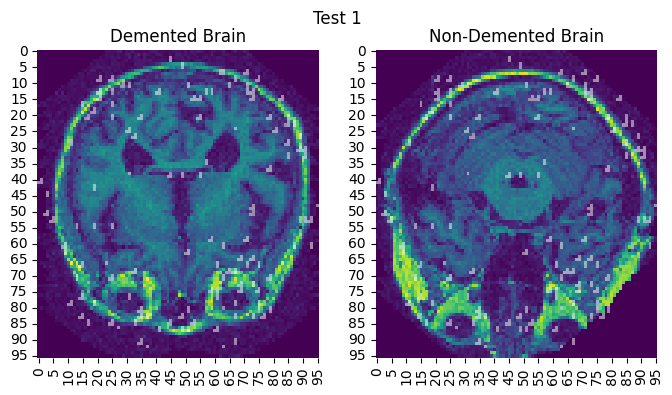

In [27]:
plot_model("Test 1", t1, np.array([K.convolve(x) for x in np.array(cor)[idx]]), Y_logit)

In [29]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
test = np.array(Y)[idx] - LinearRegression().fit(np.array(Z)[idx], np.array(Y)[idx]).predict(np.array(Z)[idx])

In [45]:
test = {k: make_scorer(v) for k, v in scorers.items()}
print(test)

{'MSE': make_scorer(mean_squared_error, response_method='predict'), 'AUC': make_scorer(auc, response_method='predict')}


In [49]:
Z

[[74.0, 0, 0.743],
 [55.0, 0, 0.81],
 [73.0, 0, 0.708],
 [28.0, 1, 0.803],
 [18.0, 1, 0.848],
 [24.0, 0, 0.862],
 [21.0, 1, 0.83],
 [20.0, 0, 0.843],
 [74.0, 1, 0.689],
 [52.0, 0, 0.827],
 [30.0, 1, 0.842],
 [81.0, 0, 0.679],
 [19.0, 0, 0.856],
 [76.0, 1, 0.719],
 [82.0, 1, 0.739],
 [21.0, 1, 0.845],
 [39.0, 1, 0.813],
 [89.0, 0, 0.715],
 [48.0, 0, 0.785],
 [80.0, 0, 0.765],
 [69.0, 0, 0.757],
 [82.0, 1, 0.71],
 [24.0, 0, 0.893],
 [58.0, 0, 0.82],
 [43.0, 0, 0.834],
 [86.0, 0, 0.738],
 [21.0, 1, 0.858],
 [65.0, 0, 0.764],
 [88.0, 1, 0.674],
 [89.0, 1, 0.682],
 [80.0, 0, 0.735],
 [51.0, 1, 0.831],
 [84.0, 0, 0.695],
 [27.0, 1, 0.842],
 [23.0, 0, 0.839],
 [70.0, 1, 0.772],
 [38.0, 0, 0.824],
 [62.0, 0, 0.758],
 [80.0, 1, 0.709],
 [21.0, 1, 0.846],
 [47.0, 0, 0.829],
 [29.0, 1, 0.829],
 [64.0, 1, 0.787],
 [57.0, 0, 0.784],
 [20.0, 0, 0.887],
 [48.0, 0, 0.841],
 [24.0, 0, 0.835],
 [78.0, 0, 0.697],
 [83.0, 0, 0.699],
 [21.0, 0, 0.848],
 [20.0, 0, 0.831],
 [72.0, 0, 0.668],
 [21.0, 0, 0.862

In [52]:
np.array(Y)[idx]>=0.5

array([False, False,  True, False, False, False,  True,  True, False,
       False, False,  True,  True,  True, False,  True, False,  True,
       False, False, False,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True, False, False, False,  True,
        True, False, False, False, False, False,  True, False, False,
       False,  True, False,  True, False, False,  True, False,  True,
       False, False, False, False, False, False,  True, False,  True,
        True,  True,  True, False, False,  True, False,  True, False,
       False,  True,  True, False,  True, False,  True,  True,  True,
       False,  True, False, False, False, False,  True, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False,  True, False, False, False,  True, False, False,
        True, False, False,  True,  True, False, False,  True, False,
       False,  True,  True, False,  True, False,  True, False, False,
       False, False,

In [30]:
test_lr = LogisticRegression()
test_lr_cv = cross_validate(test_lr, np.array(Z)[idx], np.array(Y)[idx]>=0.5, scoring={'auc': make_scorer(auc)}, return_estimator=True, cv=StratifiedKFold(n_splits=5))
display(test_lr_cv)

{'fit_time': array([0.00200319, 0.00199986, 0.00199986, 0.00199914, 0.00199938]),
 'score_time': array([0.00100064, 0.00100017, 0.00100064, 0.0010004 , 0.00100088]),
 'estimator': [LogisticRegression(),
  LogisticRegression(),
  LogisticRegression(),
  LogisticRegression(),
  LogisticRegression()],
 'test_auc': array([0.61388889, 0.60185185, 0.62037037, 0.51481481, 0.68240741])}

In [31]:
test_lr2 = LogisticRegression(fit_intercept=False)
test_lr2_cv = cross_validate(test_lr2, np.array(Z)[idx], np.array(Y)[idx]>=0.5, scoring={'auc': make_scorer(auc)}, return_estimator=True, cv=StratifiedKFold(n_splits=5))
display(test_lr2_cv)

{'fit_time': array([0.00200105, 0.00099945, 0.00099969, 0.00199962, 0.0011425 ]),
 'score_time': array([0.        , 0.00099897, 0.00100017, 0.00100064, 0.00085735]),
 'estimator': [LogisticRegression(fit_intercept=False),
  LogisticRegression(fit_intercept=False),
  LogisticRegression(fit_intercept=False),
  LogisticRegression(fit_intercept=False),
  LogisticRegression(fit_intercept=False)],
 'test_auc': array([0.55740741, 0.61388889, 0.59537037, 0.55185185, 0.68240741])}

In [36]:
print([c.coef_ for c in test_lr2_cv['estimator']])

[array([1.15628446e-02, 1.52662480e-01, 3.47872815e+01]), array([1.82577836e-02, 1.32257439e-01, 3.43035891e+01]), array([1.36839371e-02, 3.89507059e-01, 3.44527581e+01]), array([1.58606055e-02, 2.65151087e-01, 3.46344344e+01]), array([1.42817353e-02, 3.11523615e-01, 3.48845983e+01])]


In [42]:
print([t['model'].zeta for t in t1])

[array([1.15628446e-02, 1.52662480e-01, 3.47872815e+01]), array([1.82577836e-02, 1.32257439e-01, 3.43035891e+01]), array([1.36839371e-02, 3.89507059e-01, 3.44527581e+01]), array([1.58606055e-02, 2.65151087e-01, 3.46344344e+01]), array([1.42817353e-02, 3.11523615e-01, 3.48845983e+01])]


In [38]:
print([t['model'].grid_values['score']['sparsity'] for t in t1])

[0.9982638888888888, 0.9982638888888888, 0.9982638888888888, 0.9982638888888888, 0.9982638888888888]


In [39]:
Ridge(fit_intercept = False, alpha=0).fit(np.array(Z)[idx], np.array(Y)[idx]).coef_

array([1.48664563e-02, 2.49072832e-01, 3.45983498e+01])

In [40]:
LinearRegression(fit_intercept=False).fit(np.array(Z)[idx], np.array(Y)[idx]).coef_

array([1.48664563e-02, 2.49072832e-01, 3.45983498e+01])

In [137]:
idx = np.array([y is not None for y in Y])
g = Identity()
lam = [2**i for i in range(-1,4)]
test_model = CSKPD(p_list,lama=lam,lamb=lam,lamz=lam,R=3,g=g,n_cores = 12,max_iter = 15,print_iter = 5)
p_list = [[12,12],[24,24],[12,24],[24,12],[4,4], [48,48],[12,48],[48,12],[24,48],[48,24]]
y_test = np.array(Y, dtype=float)[idx]/30
z_test = np.array(Z)[idx]
cor_test = np.array(cor)[idx]
tra_test = np.array(tra)[idx]
sag_test = np.array(sag)[idx]

In [138]:
cor_model = test_model.custom_cross_validate(cor_test,y_test, scorers=scorers, k_folds=3, K=K, tol=1e-3, Z=z_test, max_vals=20)

In [139]:
tra_model = test_model.custom_cross_validate(tra_test,y_test, scorers=scorers, k_folds=3, K=K, tol=1e-3, Z=z_test, max_vals=20)

In [140]:
sag_model = test_model.custom_cross_validate(sag_test,y_test, scorers=scorers, k_folds=3, K=K, tol=1e-3, Z=z_test, max_vals=20)

In [134]:
print(cor_model[2]['results'])

{'test_MSE': array([66371.7934414 , 10195.66923579, 27218.9130999 ]), 'test_AUC': array([0.5375    , 0.5       , 0.64903846])}


In [ ]:
cor_model[1]['model'].C

array([[ 2.77022736e-03, -4.14103216e-03,  4.09830309e-04, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.64050162e-03,  5.38336117e-03, -5.32435851e-05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [19]:
Y_assumed = np.array([0 if y is None or y < 0.5 else 1 for y in Y])
print(Y_assumed)

[0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0
 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0
 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0
 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0]


In [46]:
cor_model = test_model.custom_cross_validate(np.array(cor),Y_assumed, scorers=scorers, k_folds=5, K=K, tol=1e-3, Z=np.array(Z), max_vals=20)

In [48]:
cor_results = cor_model[4]['results']['test_AUC']
print(f"{cor_results}, {np.mean(cor_results)}")

[0.5        0.5        0.83320896 0.57761194 0.76119403], 0.6344029850746269


In [49]:
cor_model[4]['model'].grid_values['score']['sparsity']

0.8269675925925926

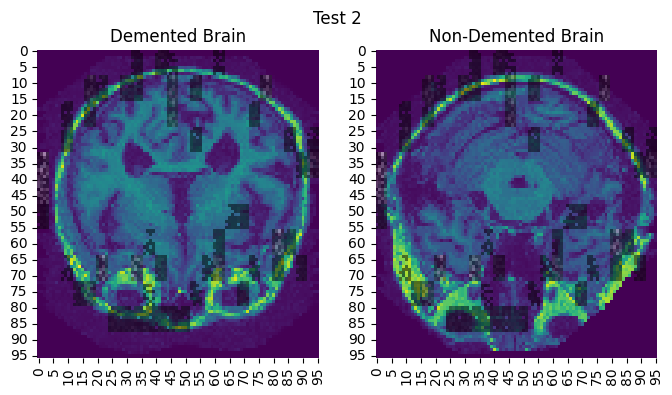

In [47]:
plot_model("Test 2", cor_model, np.array([K.convolve(x) for x in np.array(cor)]), Y_assumed)

In [39]:
t3 = test_model.custom_cross_validate(np.array(cor),Y_assumed, scorers=scorers, k_folds=5, K=K, tol=1e-3, max_vals=20)

In [40]:
np.mean(t3[4]['results']['test_AUC'])

0.5569490781387183

In [41]:
sag_model = test_model.custom_cross_validate(np.array(sag),Y_assumed, scorers=scorers, k_folds=5, K=K, tol=1e-3, Z=np.array(Z), max_vals=20)

In [43]:
sag_results = sag_model[4]['results']['test_AUC']
print(f"{sag_results}, {np.mean(sag_results)}")

[0.63088235 0.5        0.61940299 0.67910448 0.525     ], 0.5908779631255487


In [44]:
tra_model = test_model.custom_cross_validate(np.array(tra),Y_assumed, scorers=scorers, k_folds=5, K=K, tol=1e-3, Z=np.array(Z), max_vals=20)

In [45]:
tra_results = tra_model[4]['results']['test_AUC']
print(f"{tra_results}, {np.mean(tra_results)}")

[0.88235294 0.7380597  0.5        0.525      0.5       ], 0.6290825285338015


In [52]:
cor_model[np.argmax(cor_results)]['model'].C

array([[ 1.88165179e-21, -1.89903542e-20,  7.61354568e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.02038129e-21,  2.39364090e-20, -2.73129487e-20, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.01512690e-20,  1.28200494e-21, -6.44754706e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [53]:
len(Y_assumed)

436

In [63]:
from sklearn.model_selection import train_test_split

id_train, id_test, y_train, y_test = train_test_split(range(len(Y_assumed)), Y_assumed, test_size=0.2, random_state=0)
cor_y_hat = cor_model[4]['model'].predict([K.convolve(x) for x in np.array(cor)], Z=np.array(Z)[id_test])

ValueError: operands could not be broadcast together with shapes (436,) (88,) 

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import numpy as np

# Initialize base models with parameters
params_cor = {'n_estimators': 100, 'max_depth': 5}
cor_model = RandomForestClassifier(**params_cor)

params_tra = {'learning_rate': 0.1, 'n_estimators': 200}
tra_model = GradientBoostingClassifier(**params_tra)

sag_model = XGBClassifier(n_estimators=50)  # Example for third model

# Create a list of estimators
estimators = [
    ('cor', cor_model),
    ('tra', tra_model),
    ('sag', sag_model)
]

# Initialize the stacking model with the custom estimators
stacking_model = StackingClassifier(estimators=estimators, final_estimator=XGBClassifier())

# Split data into training and test sets (for example purposes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = stacking_model.predict(X_test)

# Evaluate the performance
from sklearn.metrics import accuracy_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

# For new data:
new_data = ...  # Your new data matrix
y_final_pred = stacking_model.predict(new_data)

ValueError: could not convert string to float: ' Private'

TODO: Create an array of kernels and slices and pass through in the same way as the three slices above.

In [83]:
p = tra_model[4]['model'].grid_values['p']
d = tra_model[4]['model'].grid_values['d']

KeyError: 'd'

In [84]:
A = tra_model[4]['model'].grid_values['A']
B = tra_model[4]['model'].grid_values['B']
R = 3
C = sum([np.kron(A[:,r].reshape(*p),B[:,r].reshape(d)) for r in 3])

TypeError: 'int' object is not iterable

In [ ]:
np.kron(tra_model[4]['model'].grid_values['A'], tra_model[4]['model'].grid_values['B']).shape

(96, 864)

In [85]:
tra_model[4]['model'].grid_values['A'].shape

(288, 3)

In [86]:
tra_model[4]['model'].grid_values['B'].shape

(32, 3)

In [88]:
tra_model[4]['model'].C.shape

(96, 96)